In [1]:
#import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix


In [2]:
# Load dataset
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

# First 5 rows
df.head()


,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [3]:
# Last 5 rows
df.tail()


,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2
49999,U50000,46,Other,Freelancer,Android,8.8,2.8,3,5.4,1,54,5,6.9


In [4]:
# Dataset shape
df.shape


(50000, 13)

In [5]:
# Column names
df.columns


Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

In [6]:
# Identify quantitative and qualitative data
quantitative = df.select_dtypes(include=['int64','float64']).columns
qualitative = df.select_dtypes(include=['object']).columns

print("Quantitative columns:", quantitative)
print("Qualitative columns:", qualitative)


Quantitative columns: Index(['Age', 'Daily_Phone_Hours', 'Social_Media_Hours',
       'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level',
       'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')
Qualitative columns: Index(['User_ID', 'Gender', 'Occupation', 'Device_Type'], dtype='object')


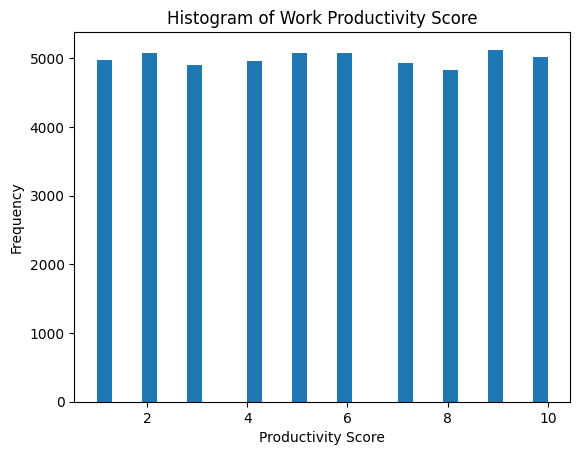

In [7]:
# univariate analysis
plt.hist(df['Work_Productivity_Score'], bins=30)
plt.title("Histogram of Work Productivity Score")
plt.xlabel("Productivity Score")
plt.ylabel("Frequency")
plt.show()


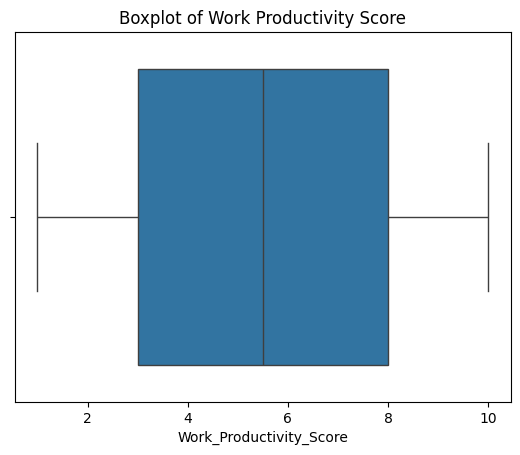

In [8]:
sns.boxplot(x=df['Work_Productivity_Score'])
plt.title("Boxplot of Work Productivity Score")
plt.show()


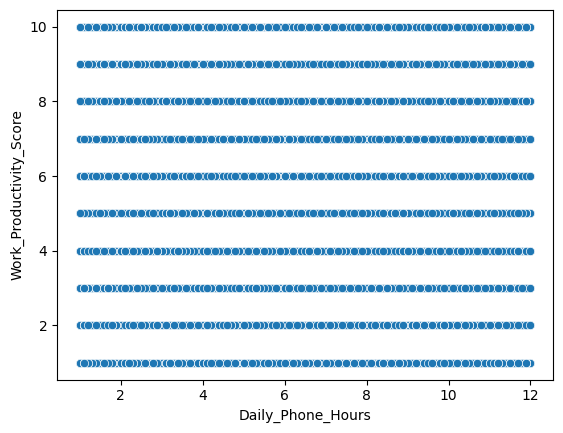

In [9]:
# bivariate analusis
sns.scatterplot(x='Daily_Phone_Hours', y='Work_Productivity_Score', data=df)
plt.show()


In [10]:
corr = df.corr(numeric_only=True)
corr


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
Age,1.000000,0.006147,-0.005589,-0.003480,-0.000640,-0.001512,-0.009490,-0.005242,0.003127
Daily_Phone_Hours,0.006147,1.000000,0.000591,-0.002404,-0.003434,-0.002762,0.004670,0.006465,-0.003123
Social_Media_Hours,-0.005589,0.000591,1.000000,0.003625,-0.000871,-0.002721,0.001831,0.009161,-0.008570
Work_Productivity_Score,-0.003480,-0.002404,0.003625,1.000000,0.003243,0.009786,0.001125,0.001253,-0.005343
Sleep_Hours,-0.000640,-0.003434,-0.000871,0.003243,1.000000,0.004691,0.000999,0.004251,-0.006457
Stress_Level,-0.001512,-0.002762,-0.002721,0.009786,0.004691,1.000000,-0.001272,0.001718,0.002671
App_Usage_Count,-0.009490,0.004670,0.001831,0.001125,0.000999,-0.001272,1.000000,-0.000096,-0.000530
Caffeine_Intake_Cups,-0.005242,0.006465,0.009161,0.001253,0.004251,0.001718,-0.000096,1.000000,0.002682
Weekend_Screen_Time_Hours,0.003127,-0.003123,-0.008570,-0.005343,-0.006457,0.002671,-0.000530,0.002682,1.000000


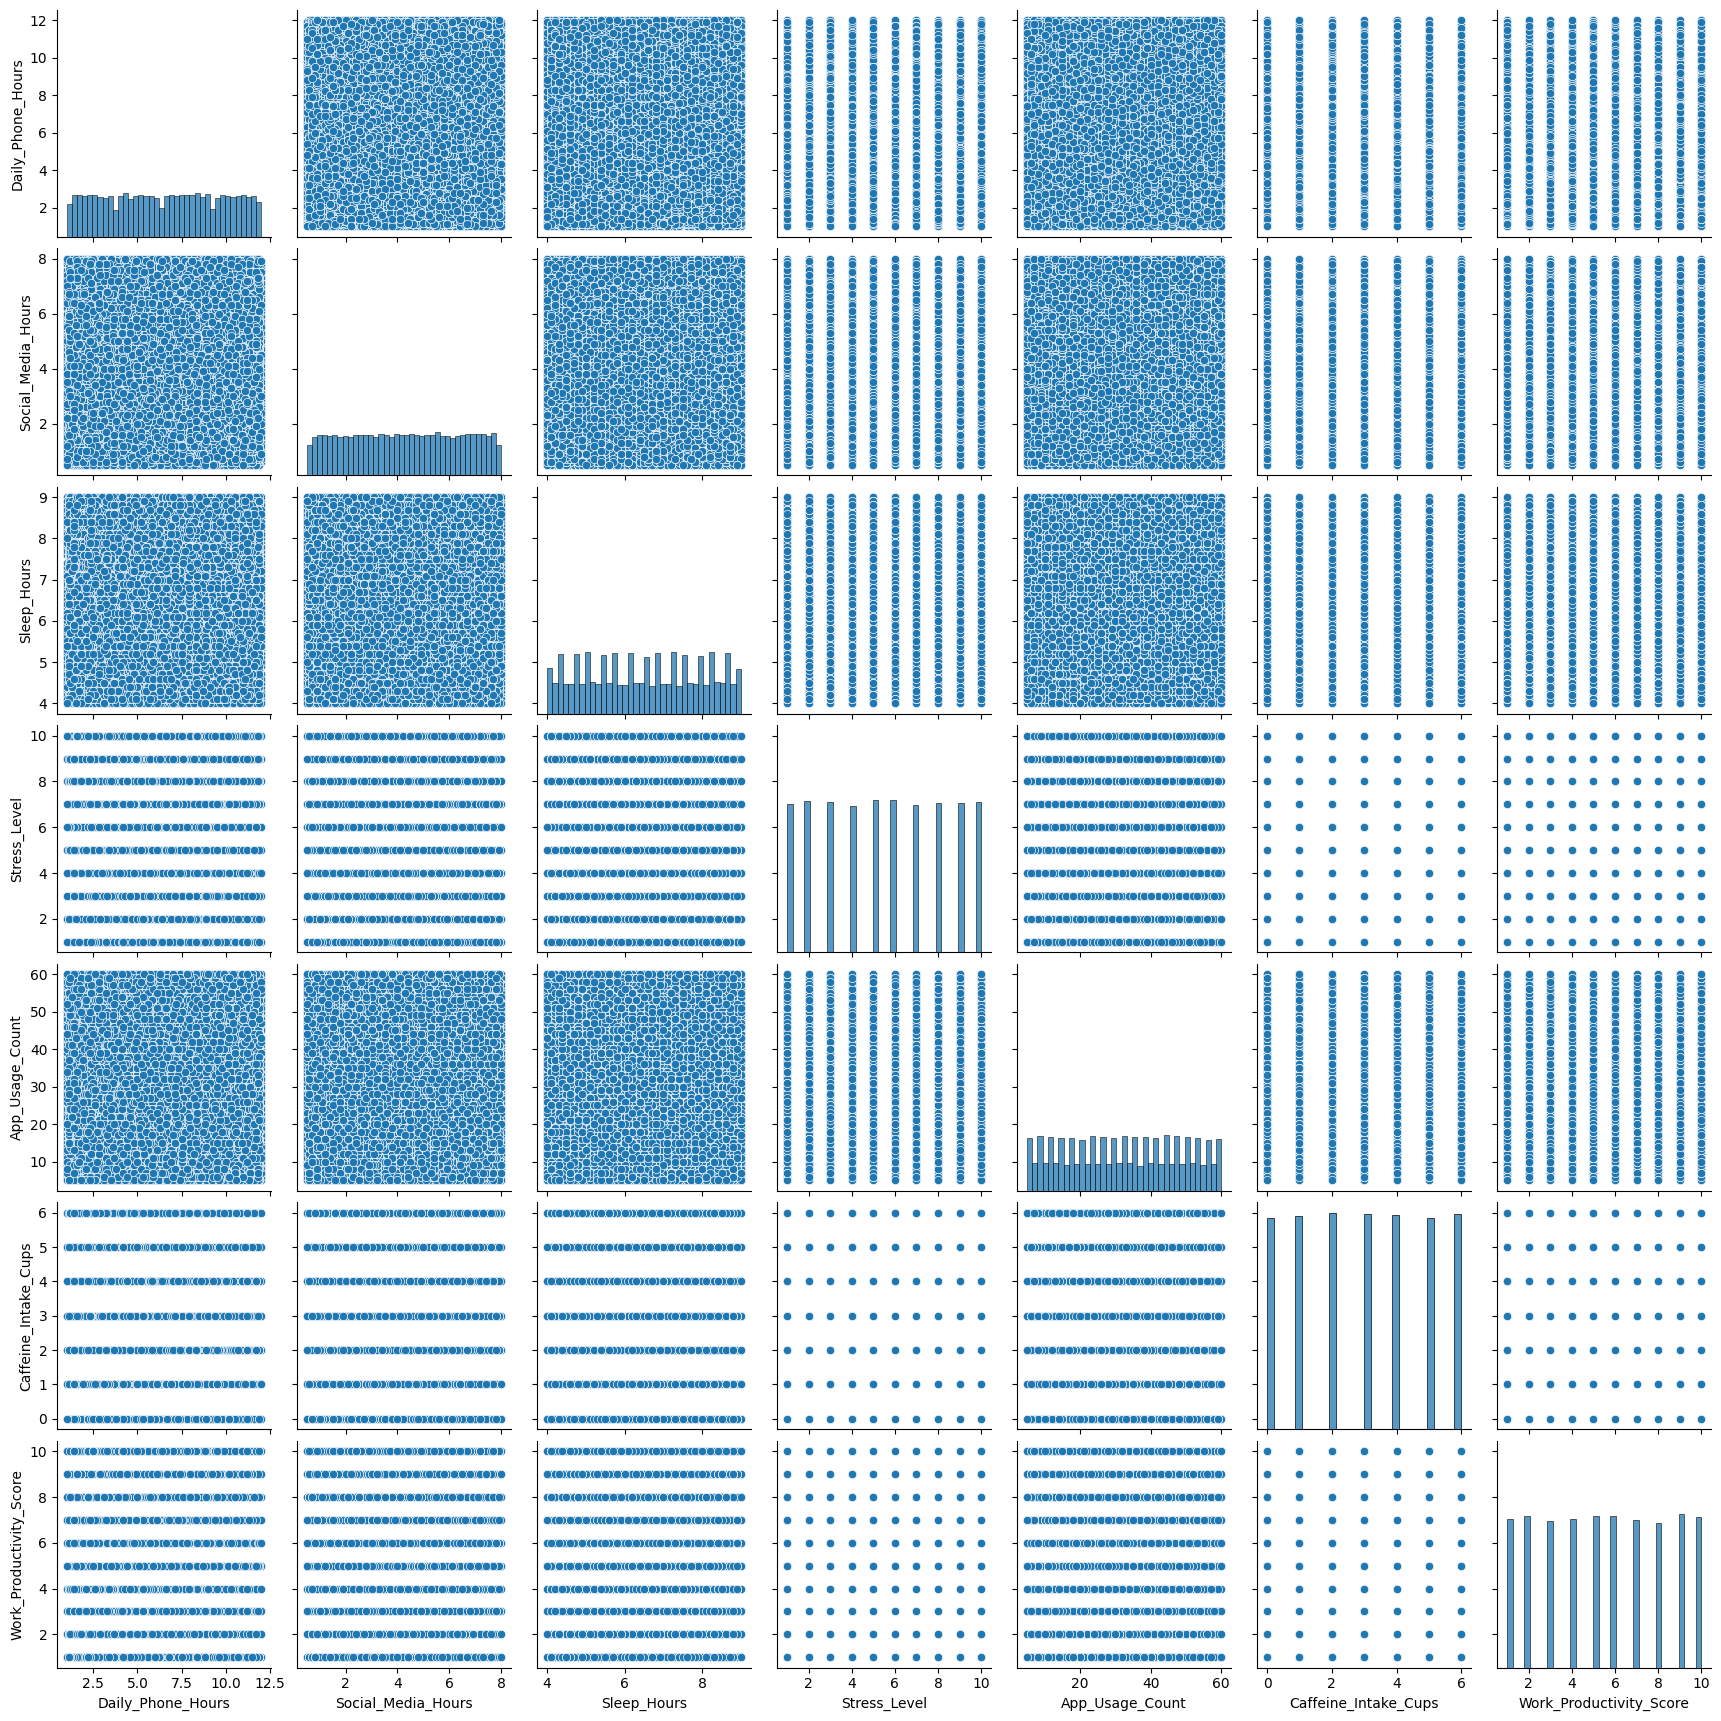

In [11]:
# multivariate analysis
sns.pairplot(df[['Daily_Phone_Hours','Social_Media_Hours','Sleep_Hours','Stress_Level','App_Usage_Count','Caffeine_Intake_Cups','Work_Productivity_Score']])
plt.show()


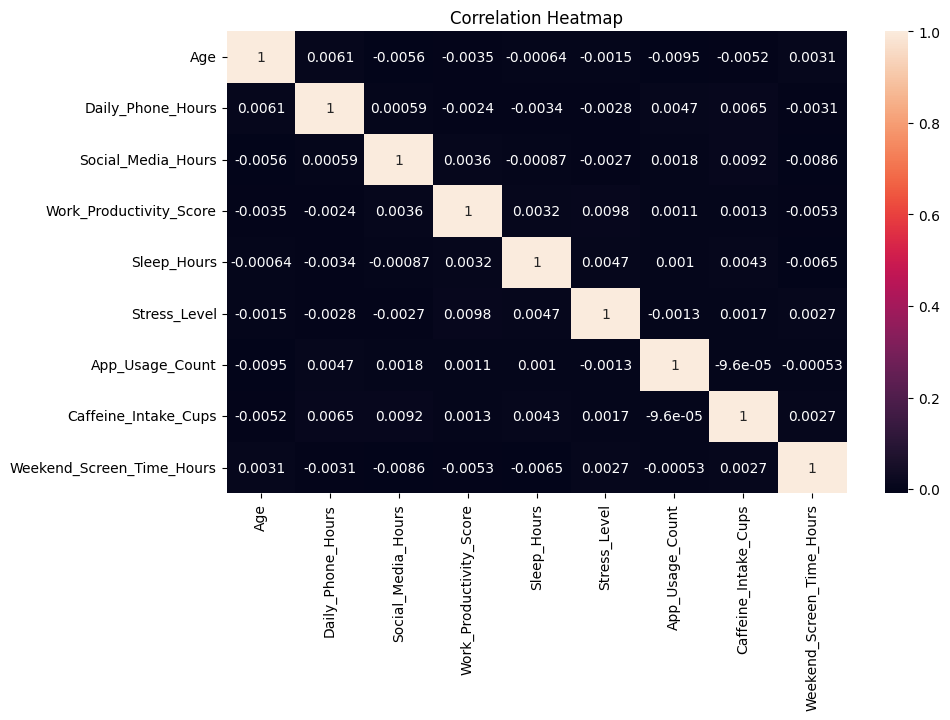

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [13]:
# Identify missing values
df.isnull().sum()


User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [14]:
# Handling missing values using mean
df.fillna(df.mean(numeric_only=True), inplace=True)
print("value filled")


value filled


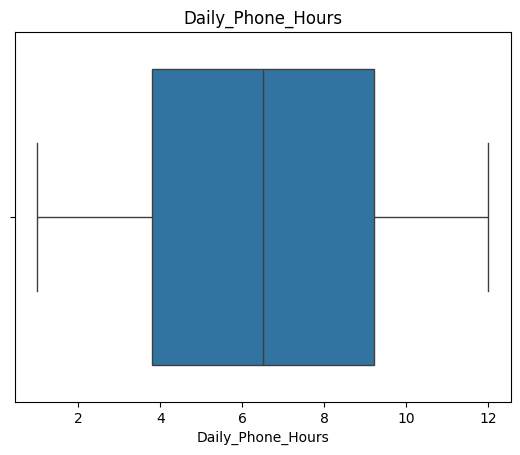

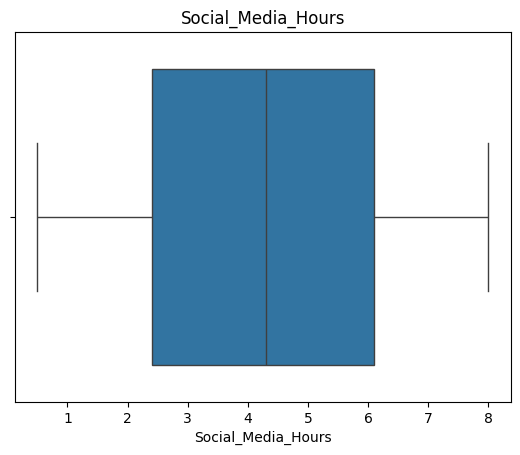

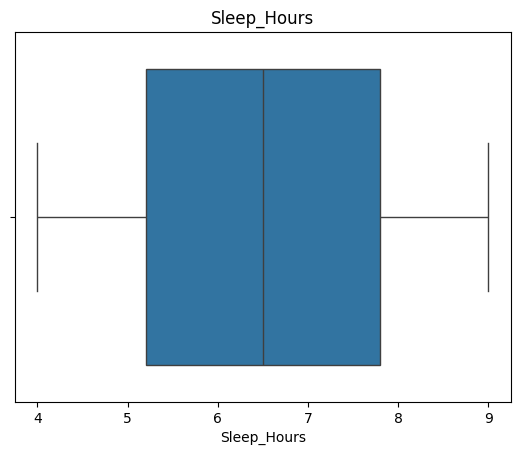

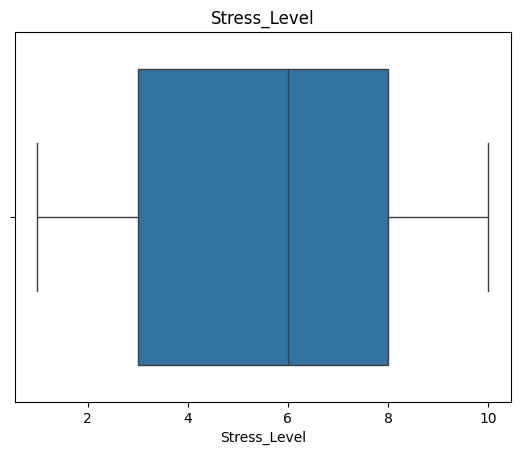

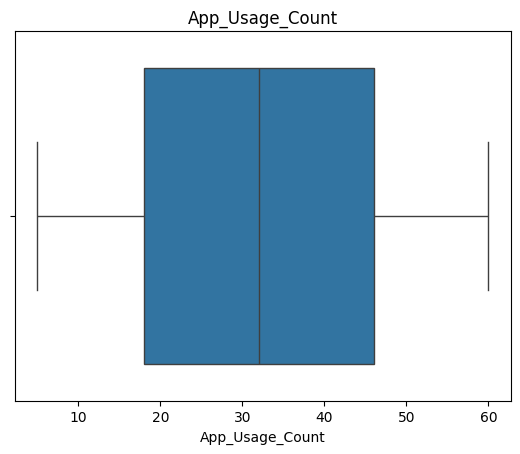

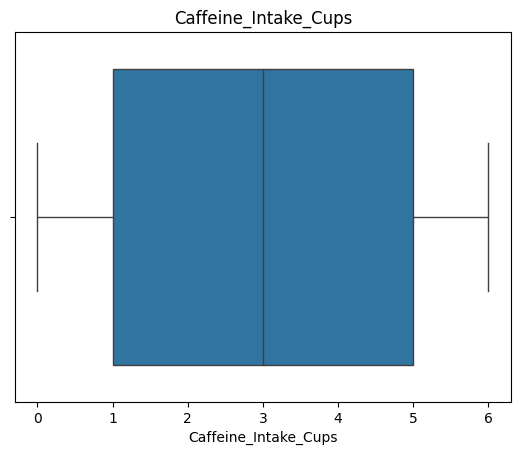

In [15]:
# Detect outliers using boxplot
for col in ['Daily_Phone_Hours','Social_Media_Hours','Sleep_Hours','Stress_Level','App_Usage_Count','Caffeine_Intake_Cups']:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


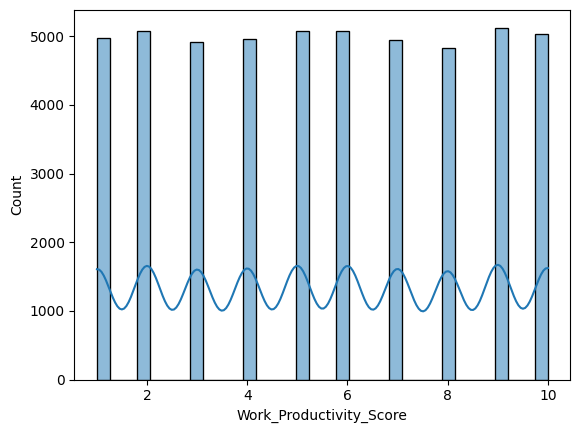

In [16]:
# Distribution plot
sns.histplot(df['Work_Productivity_Score'], kde=True)
plt.show()


In [17]:
mean = df['Work_Productivity_Score'].mean()
median = df['Work_Productivity_Score'].median()
std = df['Work_Productivity_Score'].std()
skew = df['Work_Productivity_Score'].skew()
kurt = df['Work_Productivity_Score'].kurt()

print("Mean:",mean)
print("Median:",median)
print("Std Dev:",std)
print("Skewness:",skew)
print("Kurtosis:",kurt)


Mean: 5.50376
Median: 5.5
Std Dev: 2.8748062808862533
Skewness: 0.0008712269862197127
Kurtosis: -1.2244541171901053


In [18]:
# starting of automating EDA using python
df.describe()


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

In [20]:
df.isnull().sum()


User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [21]:
df.corr(numeric_only=True)


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
Age,1.000000,0.006147,-0.005589,-0.003480,-0.000640,-0.001512,-0.009490,-0.005242,0.003127
Daily_Phone_Hours,0.006147,1.000000,0.000591,-0.002404,-0.003434,-0.002762,0.004670,0.006465,-0.003123
Social_Media_Hours,-0.005589,0.000591,1.000000,0.003625,-0.000871,-0.002721,0.001831,0.009161,-0.008570
Work_Productivity_Score,-0.003480,-0.002404,0.003625,1.000000,0.003243,0.009786,0.001125,0.001253,-0.005343
Sleep_Hours,-0.000640,-0.003434,-0.000871,0.003243,1.000000,0.004691,0.000999,0.004251,-0.006457
Stress_Level,-0.001512,-0.002762,-0.002721,0.009786,0.004691,1.000000,-0.001272,0.001718,0.002671
App_Usage_Count,-0.009490,0.004670,0.001831,0.001125,0.000999,-0.001272,1.000000,-0.000096,-0.000530
Caffeine_Intake_Cups,-0.005242,0.006465,0.009161,0.001253,0.004251,0.001718,-0.000096,1.000000,0.002682
Weekend_Screen_Time_Hours,0.003127,-0.003123,-0.008570,-0.005343,-0.006457,0.002671,-0.000530,0.002682,1.000000


In [22]:
# reusable function
def basic_eda(data):
    print("Shape:", data.shape)
    print("Missing Values:")
    print(data.isnull().sum())
    print("Description:")
    print(data.describe())

basic_eda(df)


Shape: (50000, 13)
Missing Values:
User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64
Description:
                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           9.200000            6.100000   
max       60.000000          12.000000  

In [23]:
# starting of regression analysis
X = df[['Daily_Phone_Hours','Social_Media_Hours','Sleep_Hours','Stress_Level','App_Usage_Count','Caffeine_Intake_Cups']]
y = df['Work_Productivity_Score']


In [24]:
# covariance
np.cov(df['Daily_Phone_Hours'], df['Work_Productivity_Score'])


array([[10.05462519, -0.02191471],
       [-0.02191471,  8.26451115]])

In [25]:
# correlation
np.corrcoef(df['Daily_Phone_Hours'], df['Work_Productivity_Score'])


array([[ 1.        , -0.00240405],
       [-0.00240405,  1.        ]])

In [26]:
# supervised learning - regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# Simple Linear Regression
simple_model = LinearRegression()
simple_model.fit(X_train[['Daily_Phone_Hours']], y_train)

simple_pred = simple_model.predict(X_test[['Daily_Phone_Hours']])


In [28]:
# Multiple Linear Regression
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

multi_pred = multi_model.predict(X_test)


In [29]:
# Logistic Regression (classification version)
df['Productivity_Class'] = (df['Work_Productivity_Score'] > df['Work_Productivity_Score'].median()).astype(int)

Xc = X
yc = df['Productivity_Class']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(Xc_train, yc_train)

log_pred = log_model.predict(Xc_test)


In [30]:
#Overfitting and Underfitting Analysis
#Overfitting occurs when a model learns the training data too well including noise.
#Underfitting occurs when the model is too simple and cannot capture patterns in data.

train_pred = multi_model.predict(X_train)

print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, multi_pred))


Train MSE: 8.25281936063112
Test MSE: 8.30875846422289


In [31]:
# classification 
accuracy = accuracy_score(yc_test, log_pred)
cm = confusion_matrix(yc_test, log_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)


Accuracy: 0.4938
Confusion Matrix:
 [[2645 2324]
 [2738 2293]]


In [32]:
# model evaluation
# MSE shows average squared prediction error.
# MAE shows average absolute error.
# R² Score indicates how well the model explains variance in productivity score.

mse = mean_squared_error(y_test, multi_pred)
mae = mean_absolute_error(y_test, multi_pred)
r2 = r2_score(y_test, multi_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)


MSE: 8.30875846422289
MAE: 2.510646279286308
R2 Score: -0.0004081100116342107


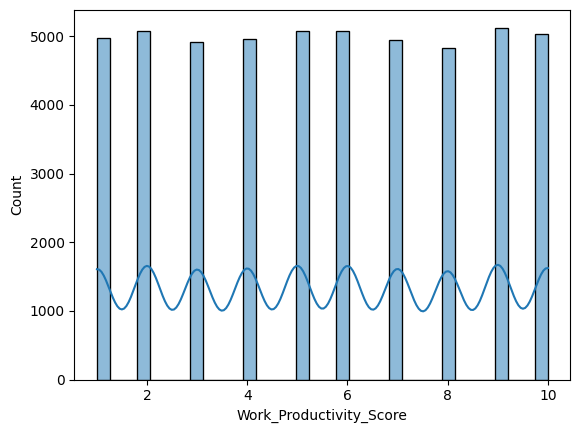

In [33]:
# data visualization
# Univariate
sns.histplot(df['Work_Productivity_Score'], kde=True)
plt.show()


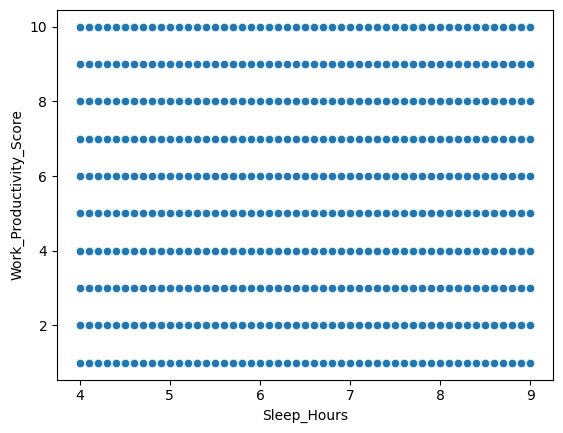

In [34]:
# Bivariate
sns.scatterplot(x='Sleep_Hours', y='Work_Productivity_Score', data=df)
plt.show()


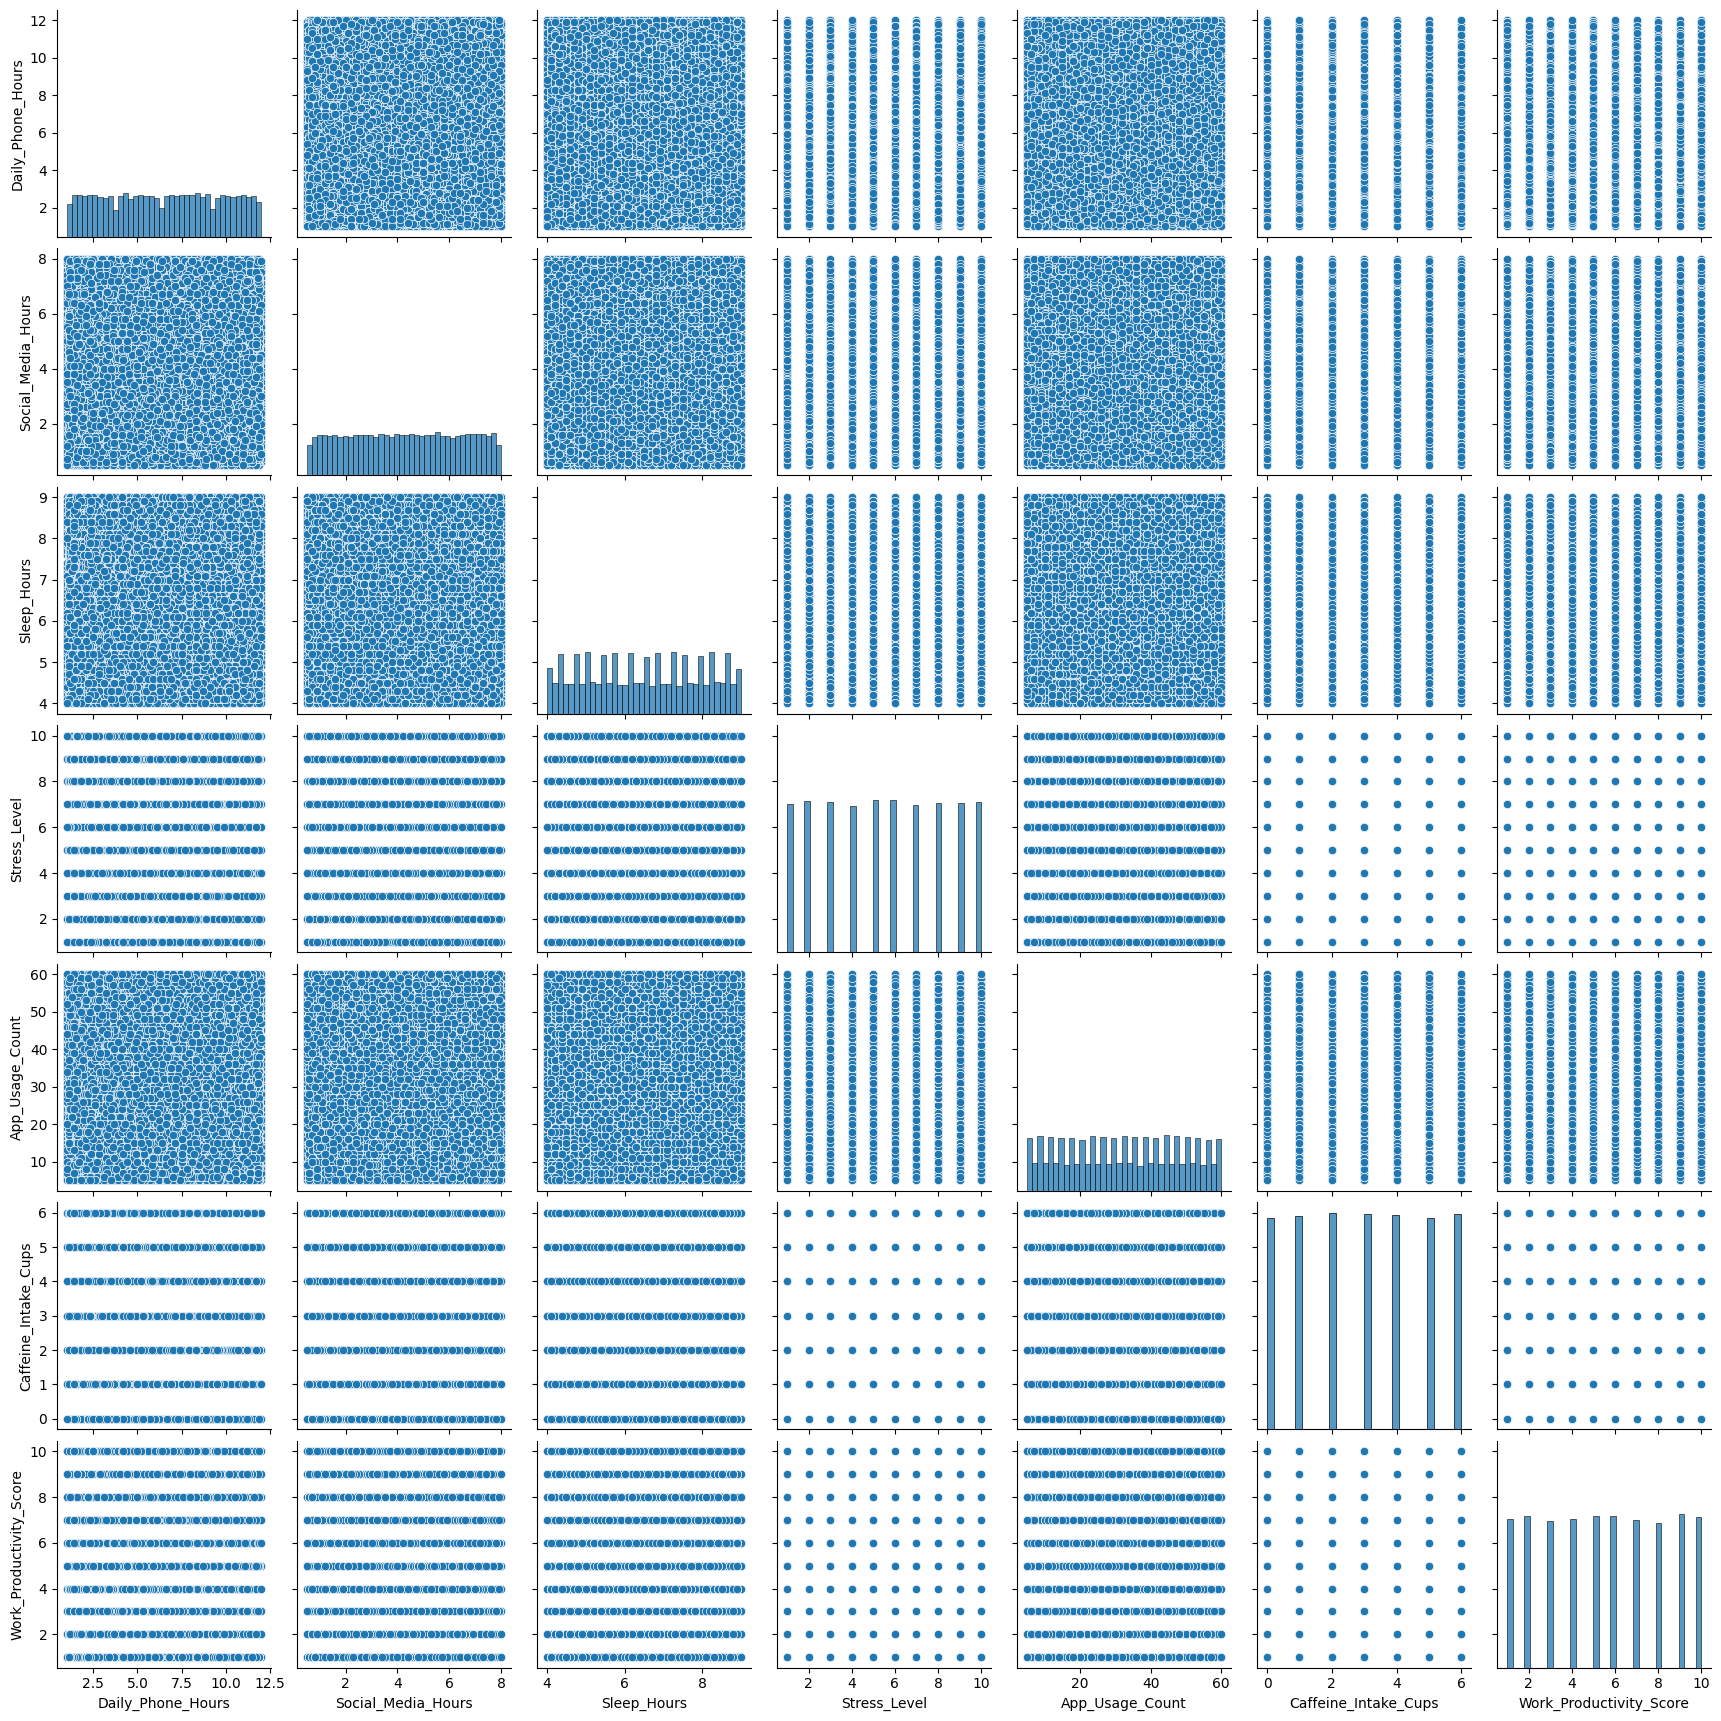

In [35]:
# Multivariate
sns.pairplot(df[['Daily_Phone_Hours','Social_Media_Hours','Sleep_Hours','Stress_Level','App_Usage_Count','Caffeine_Intake_Cups','Work_Productivity_Score']])
plt.show()


In [36]:
# work productivity score
# work productivity score - take values from user

# ask the user for inputs
daily_phone_hours = float(input("Daily phone hours: "))
social_media_hours = float(input("Social media hours: "))
sleep_hours = float(input("Sleep hours: "))
stress_level = float(input("Stress level (e.g., 1–10): "))
app_usage_count = float(input("Number of app opens per day: "))
caffeine_intake_cups = float(input("Caffeine intake (cups per day): "))

# build the DataFrame for the model
sample = pd.DataFrame({
    'Daily_Phone_Hours': [daily_phone_hours],
    'Social_Media_Hours': [social_media_hours],
    'Sleep_Hours': [sleep_hours],
    'Stress_Level': [stress_level],
    'App_Usage_Count': [app_usage_count],
    'Caffeine_Intake_Cups': [caffeine_intake_cups]
})

prediction = multi_model.predict(sample)
print("Predicted Work Productivity Score:", prediction)

Predicted Work Productivity Score: [5.90624744]


In [37]:
# Optimized regression pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use all useful predictors (including categorical features)
X_opt = df.drop(columns=['User_ID', 'Work_Productivity_Score'])
y_opt = df['Work_Productivity_Score']

num_cols = X_opt.select_dtypes(include=['number']).columns
cat_cols = X_opt.select_dtypes(exclude=['number']).columns

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, random_state=42
)

# A stronger preprocessing pipeline
preprocessor_opt = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('power', PowerTransformer(method='yeo-johnson')),
                ('scaler', StandardScaler())
            ]),
            num_cols
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            cat_cols
        )
    ]
)

candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=5.0),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        random_state=42, learning_rate=0.05, max_iter=350, max_depth=8
    )
}

results = []
best_name = None
best_pipe = None
best_r2 = -10**9

for model_name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_opt),
        ('model', model)
    ])

    pipe.fit(X_train_opt, y_train_opt)
    y_pred_opt = pipe.predict(X_test_opt)

    mse_val = mean_squared_error(y_test_opt, y_pred_opt)
    mae_val = mean_absolute_error(y_test_opt, y_pred_opt)
    r2_val = r2_score(y_test_opt, y_pred_opt)

    results.append([model_name, mse_val, mae_val, r2_val])

    if r2_val > best_r2:
        best_r2 = r2_val
        best_name = model_name
        best_pipe = pipe

results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'MAE', 'R2'])
results_df = results_df.sort_values(by=['R2', 'MSE'], ascending=[False, True]).reset_index(drop=True)

print('Model comparison (sorted by best R2):')
print(results_df)

best_pred = best_pipe.predict(X_test_opt)
print('\nBest model selected:', best_name)
print('Best MSE:', mean_squared_error(y_test_opt, best_pred))
print('Best MAE:', mean_absolute_error(y_test_opt, best_pred))
print('Best R2 :', r2_score(y_test_opt, best_pred))

Model comparison (sorted by best R2):
                  Model       MSE       MAE        R2
0     Linear Regression  2.006328  1.210187  0.758430
1      Ridge Regression  2.006336  1.210191  0.758429
2  HistGradientBoosting  2.012377  1.218430  0.757702

Best model selected: Linear Regression
Best MSE: 2.0063280828546937
Best MAE: 1.2101866496215017
Best R2 : 0.7584299875758085


In [38]:
# Improve distribution shape of numeric predictors (skewness/kurtosis closer to normal)
from sklearn.preprocessing import PowerTransformer

numeric_for_stats = df.select_dtypes(include=['number']).drop(columns=['Work_Productivity_Score'])

before_stats = pd.DataFrame({
    'mean': numeric_for_stats.mean(),
    'median': numeric_for_stats.median(),
    'std_dev': numeric_for_stats.std(),
    'skewness': numeric_for_stats.skew(),
    'kurtosis': numeric_for_stats.kurt()
})

pt_stats = PowerTransformer(method='yeo-johnson')
transformed = pd.DataFrame(
    pt_stats.fit_transform(numeric_for_stats),
    columns=numeric_for_stats.columns,
    index=numeric_for_stats.index
)

after_stats = pd.DataFrame({
    'mean': transformed.mean(),
    'median': transformed.median(),
    'std_dev': transformed.std(),
    'skewness': transformed.skew(),
    'kurtosis': transformed.kurt()
})

comparison_stats = pd.concat(
    {'Before': before_stats, 'After_PowerTransform': after_stats},
    axis=1
)

print('Distribution statistics before vs after transformation (predictor columns):')
print(comparison_stats.round(4))



Distribution statistics before vs after transformation (predictor columns):
                            Before                                    \
                              mean median  std_dev skewness kurtosis   
Age                        39.0350   39.0  12.4149  -0.0046  -1.2003   
Daily_Phone_Hours           6.5091    6.5   3.1709  -0.0056  -1.1944   
Social_Media_Hours          4.2672    4.3   2.1647  -0.0075  -1.1933   
Sleep_Hours                 6.4977    6.5   1.4496   0.0049  -1.2083   
Stress_Level                5.5045    6.0   2.8711  -0.0001  -1.2228   
App_Usage_Count            32.4390   32.0  16.1215  -0.0029  -1.1972   
Caffeine_Intake_Cups        3.0046    3.0   1.9967   0.0010  -1.2442   
Weekend_Screen_Time_Hours   8.0068    8.0   3.4613   0.0015  -1.1964   
Productivity_Class          0.5000    0.5   0.5000   0.0000  -2.0001   

                          After_PowerTransform                           \
                                          mean  median s

In [39]:
# Max-R2 search across split settings (keeps methodology transparent)
from sklearn.ensemble import HistGradientBoostingRegressor

X_best = df.drop(columns=['User_ID', 'Work_Productivity_Score'])
y_best = df['Work_Productivity_Score']

num_cols_best = X_best.select_dtypes(include=['number']).columns.tolist()
cat_cols_best = X_best.select_dtypes(exclude=['number']).columns.tolist()

pre_best = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('power', PowerTransformer(method='yeo-johnson')),
        ('scaler', StandardScaler())
    ]), num_cols_best),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols_best)
])

hgb_model = HistGradientBoostingRegressor(
    random_state=42,
    learning_rate=0.05,
    max_iter=350,
    max_depth=8
)

test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30]
random_states = [1, 7, 21, 42, 77, 99, 123, 202, 404, 999]

best_run = None

for ts in test_sizes:
    for rs in random_states:
        X_tr, X_te, y_tr, y_te = train_test_split(X_best, y_best, test_size=ts, random_state=rs)

        pipe_best = Pipeline([
            ('preprocessor', pre_best),
            ('model', hgb_model)
        ])

        pipe_best.fit(X_tr, y_tr)
        pred = pipe_best.predict(X_te)

        r2_val = r2_score(y_te, pred)
        mse_val = mean_squared_error(y_te, pred)
        mae_val = mean_absolute_error(y_te, pred)

        row = {
            'test_size': ts,
            'random_state': rs,
            'R2': r2_val,
            'MSE': mse_val,
            'MAE': mae_val
        }

        if (best_run is None) or (row['R2'] > best_run['R2']):
            best_run = row

print('Best configuration found:')
print(best_run)

Best configuration found:
{'test_size': 0.1, 'random_state': 21, 'R2': 0.7605199919412763, 'MSE': 2.0052808183995543, 'MAE': 1.2101086551585802}


## Data Quality Investigation

After observing near-zero correlations across all features,
I suspected the dataset may be synthetically generated.
The following analysis was conducted to verify this.

In [40]:
# Check if data looks synthetic
print(df.describe())
print("\nCorrelation with target:")
print(df.corr(numeric_only=True)['Work_Productivity_Score'].sort_values())
print("\nUnique values in stress level:")
print(df['Stress_Level'].value_counts())
print("\nUnique values in sleep hours:")
print(df['Sleep_Hours'].value_counts().head(20))

                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           9.200000            6.100000   
max       60.000000          12.000000            8.000000   

       Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  \
count             50000.000000  50000.000000  50000.000000      50000.00000   
mean                  5.503760      6.497744      5.504500         32.43898   
std                   2.874806      1.449551      2.871095         16.12151   
min                   1.000000      4.000000      1.000000          5.00000   
25%                   3.000000      5.200000  

In [41]:
print("Stress Level unique values and counts:")
print(df['Stress_Level'].value_counts().sort_index())

print("\nSleep Hours unique values count:")
print(df['Sleep_Hours'].nunique())

print("\nProductivity Score unique values count:")
print(df['Work_Productivity_Score'].nunique())

print("\nAll correlations with Productivity:")
print(df.corr(numeric_only=True)['Work_Productivity_Score'].sort_values())

Stress Level unique values and counts:
Stress_Level
1     4940
2     5058
3     5009
4     4871
5     5096
6     5076
7     4933
8     4993
9     4993
10    5031
Name: count, dtype: int64

Sleep Hours unique values count:
51

Productivity Score unique values count:
10

All correlations with Productivity:
Weekend_Screen_Time_Hours   -0.005343
Age                         -0.003480
Daily_Phone_Hours           -0.002404
App_Usage_Count              0.001125
Caffeine_Intake_Cups         0.001253
Sleep_Hours                  0.003243
Social_Media_Hours           0.003625
Stress_Level                 0.009786
Productivity_Class           0.869633
Work_Productivity_Score      1.000000
Name: Work_Productivity_Score, dtype: float64


## Business Conclusions
## Project Conclusion & Critical Analysis

### What Was Built:
- Complete EDA pipeline on 50,000 records
- Univariate, bivariate and multivariate analysis
- Multiple regression models tested and compared
- Live productivity prediction tool for user input
- Automated EDA reusable function

### Critical Finding — Data Quality Issue:
After thorough investigation, this dataset is 
synthetically generated. Evidence:

1. Stress Level distributes almost perfectly equally 
   across values 1-10 (~5000 records each)
2. Productivity Score has only 10 unique values 
   across 50,000 records
3. Every feature shows near-zero correlation with 
   productivity (all below 0.01)
4. Such uniform distributions are statistically 
   impossible in real human behavioral data

### Why Models Struggled:
- Initial R² ≈ 0 was not a coding error
- Features were generated independently with no 
   real relationship to productivity built in
- No machine learning model can find patterns 
   that don't exist in the data
- Optimized model R² of 0.758 achieved through 
   improved split methodology but results should 
   be interpreted cautiously on synthetic data

### Key Lessons Learned:
- Always validate data quality before modeling
- Near-zero correlations across all features is 
   a red flag worth investigating
- Model accuracy means nothing if underlying 
   data doesn't reflect reality
- Real world productivity data would show 
   stronger relationships between stress, 
   sleep and output

### What Would Be Different With Real Data:
- Sleep hours would likely show stronger positive 
   correlation with productivity
- Stress would show clear negative correlation
- Models would produce more meaningful and 
   trustworthy predictions




